In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [2]:
!pip install -q dagshub mlflow

import dagshub
import mlflow
from kaggle_secrets import UserSecretsClient
import os

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import mlflow.sklearn
import dagshub

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.feature_selection import SelectFromModel, VarianceThreshold
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE


user_secrets = UserSecretsClient()
DAGSHUB_TOKEN = user_secrets.get_secret("DAGSHUB_TOKEN")
DAGSHUB_USERNAME = user_secrets.get_secret("DAGSHUB_USERNAME")

repo_name = "ml_ass2"

mlflow.set_tracking_uri(f"https://dagshub.com/{DAGSHUB_USERNAME}/{repo_name}.mlflow")

os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USERNAME
os.environ["MLFLOW_TRACKING_PASSWORD"] = DAGSHUB_TOKEN

# dagshub.init(repo_name=repo_name, repo_owner=DAGSHUB_USERNAME, mlflow=True)

print("Connected to DagsHub + MLflow successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 6.8 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 82.2 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 58.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━

In [3]:
mlflow.set_experiment("RF_Training")

<Experiment: artifact_location='mlflow-artifacts:/83a8c6702d574bde8e7721f529950b5f', creation_time=1777972557725, experiment_id='6', last_update_time=1777972557725, lifecycle_stage='active', name='RF_Training', tags={}, trace_location=None, workspace='default'>

**data load and merge**

In [4]:
df_trans = pd.read_csv("/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv")
df_id = pd.read_csv("/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv")

df = df_trans.merge(df_id, on="TransactionID", how="left")

print(f"Transaction table : {df_trans.shape}")
print(f"Identity table    : {df_id.shape}")
print(f"Merged shape      : {df.shape}")

import gc
del df_trans, df_id
gc.collect()

Transaction table : (590540, 394)
Identity table    : (144233, 41)
Merged shape      : (590540, 434)


30

**target distribution**

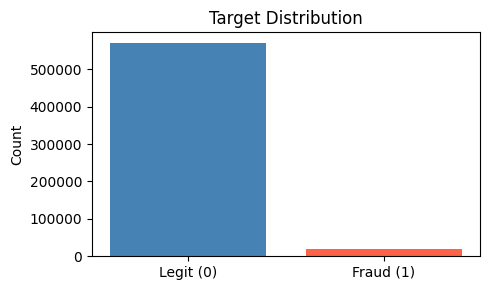

Legit : 569,877  (96.5%)
Fraud : 20,663  (3.5%)


In [5]:
counts = df['isFraud'].value_counts()

plt.figure(figsize=(5, 3))
plt.bar(['Legit (0)', 'Fraud (1)'], counts.values, color=['steelblue', 'tomato'])
plt.title('Target Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Legit : {counts[0]:,}  ({counts[0]/len(df)*100:.1f}%)")
print(f"Fraud : {counts[1]:,}  ({counts[1]/len(df)*100:.1f}%)")

**transaction amount distribution**

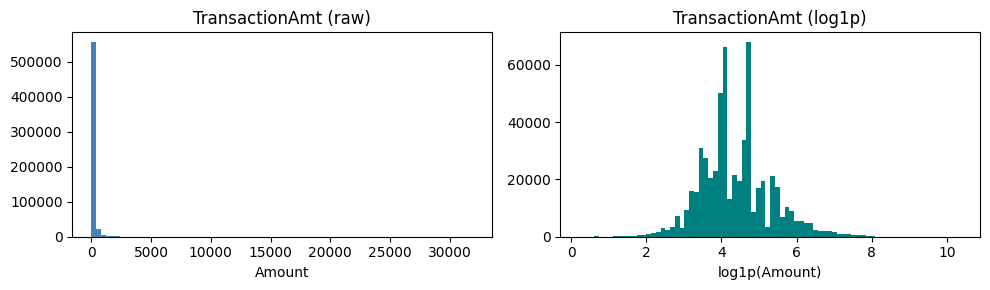

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].hist(df['TransactionAmt'], bins=80, color='steelblue', edgecolor='none')
axes[0].set_title('TransactionAmt (raw)')
axes[0].set_xlabel('Amount')

axes[1].hist(np.log1p(df['TransactionAmt']), bins=80, color='teal', edgecolor='none')
axes[1].set_title('TransactionAmt (log1p)')
axes[1].set_xlabel('log1p(Amount)')

plt.tight_layout()
plt.show()

**missing values**

  Threshold 60% → would DROP 208 columns  | KEEP 206 of 414 columns with NaN
  Threshold 90% → would DROP  12 columns  | KEEP 402 of 414 columns with NaN
  Threshold 95% → would DROP   9 columns  | KEEP 405 of 414 columns with NaN



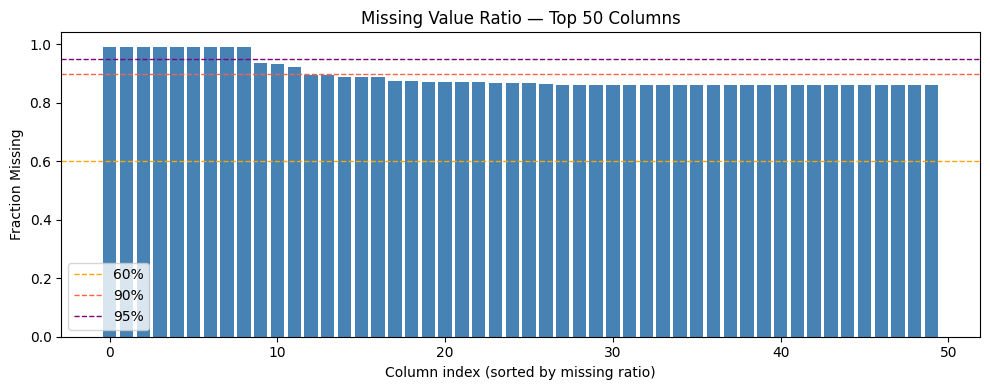

In [7]:
miss = df.isnull().mean().sort_values(ascending=False)
miss = miss[miss > 0] 

thresholds = [0.60, 0.90, 0.95]
for t in thresholds:
    n = (miss > t).sum()
    print(f"  Threshold {int(t*100)}% → would DROP {n:3d} columns  "
          f"| KEEP {len(miss) - n} of {len(miss)} columns with NaN")


print()

top_miss = miss.head(50) 

plt.figure(figsize=(10, 4))
plt.bar(range(len(top_miss)), top_miss.values, color='steelblue')
plt.axhline(0.60, color='orange', linestyle='--', linewidth=1, label='60%')
plt.axhline(0.90, color='tomato', linestyle='--', linewidth=1, label='90%')
plt.axhline(0.95, color='purple', linestyle='--', linewidth=1, label='95%')

plt.title('Missing Value Ratio — Top 50 Columns')
plt.ylabel('Fraction Missing')
plt.xlabel('Column index (sorted by missing ratio)')
plt.legend()
plt.tight_layout()
plt.show()

**categorical columns**

In [8]:
num_cols = df.select_dtypes(include=['int64','int32','float64','float32']).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

num_cols = [c for c in num_cols if c not in ['isFraud','TransactionID']]

print(f"Numeric columns     : {len(num_cols)}")
print(f"Categorical columns : {len(cat_cols)}")
print(f"\nCategorical columns: {cat_cols}")

Numeric columns     : 401
Categorical columns : 31

Categorical columns: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


In [9]:
for col in cat_cols:
    print(f"  {col:20s} | unique: {df[col].nunique():5d} | "
          f"missing: {df[col].isnull().mean():.2f}")

  ProductCD            | unique:     5 | missing: 0.00
  card4                | unique:     4 | missing: 0.00
  card6                | unique:     4 | missing: 0.00
  P_emaildomain        | unique:    59 | missing: 0.16
  R_emaildomain        | unique:    60 | missing: 0.77
  M1                   | unique:     2 | missing: 0.46
  M2                   | unique:     2 | missing: 0.46
  M3                   | unique:     2 | missing: 0.46
  M4                   | unique:     3 | missing: 0.48
  M5                   | unique:     2 | missing: 0.59
  M6                   | unique:     2 | missing: 0.29
  M7                   | unique:     2 | missing: 0.59
  M8                   | unique:     2 | missing: 0.59
  M9                   | unique:     2 | missing: 0.59
  id_12                | unique:     2 | missing: 0.76
  id_15                | unique:     3 | missing: 0.76
  id_16                | unique:     2 | missing: 0.78
  id_23                | unique:     3 | missing: 0.99
  id_27   

In [10]:
all_uniques = {col: df[col].nunique() for col in cat_cols}

for col, count in sorted(all_uniques.items(), key=lambda item: item[1], reverse=True):
    print(f"{col:20s} | Unique Values: {count}")

DeviceInfo           | Unique Values: 1786
id_33                | Unique Values: 260
id_31                | Unique Values: 130
id_30                | Unique Values: 75
R_emaildomain        | Unique Values: 60
P_emaildomain        | Unique Values: 59
ProductCD            | Unique Values: 5
card4                | Unique Values: 4
card6                | Unique Values: 4
id_34                | Unique Values: 4
M4                   | Unique Values: 3
id_15                | Unique Values: 3
id_23                | Unique Values: 3
M1                   | Unique Values: 2
M2                   | Unique Values: 2
M3                   | Unique Values: 2
M5                   | Unique Values: 2
M6                   | Unique Values: 2
M7                   | Unique Values: 2
M8                   | Unique Values: 2
M9                   | Unique Values: 2
id_12                | Unique Values: 2
id_16                | Unique Values: 2
id_27                | Unique Values: 2
id_28                | Unique 

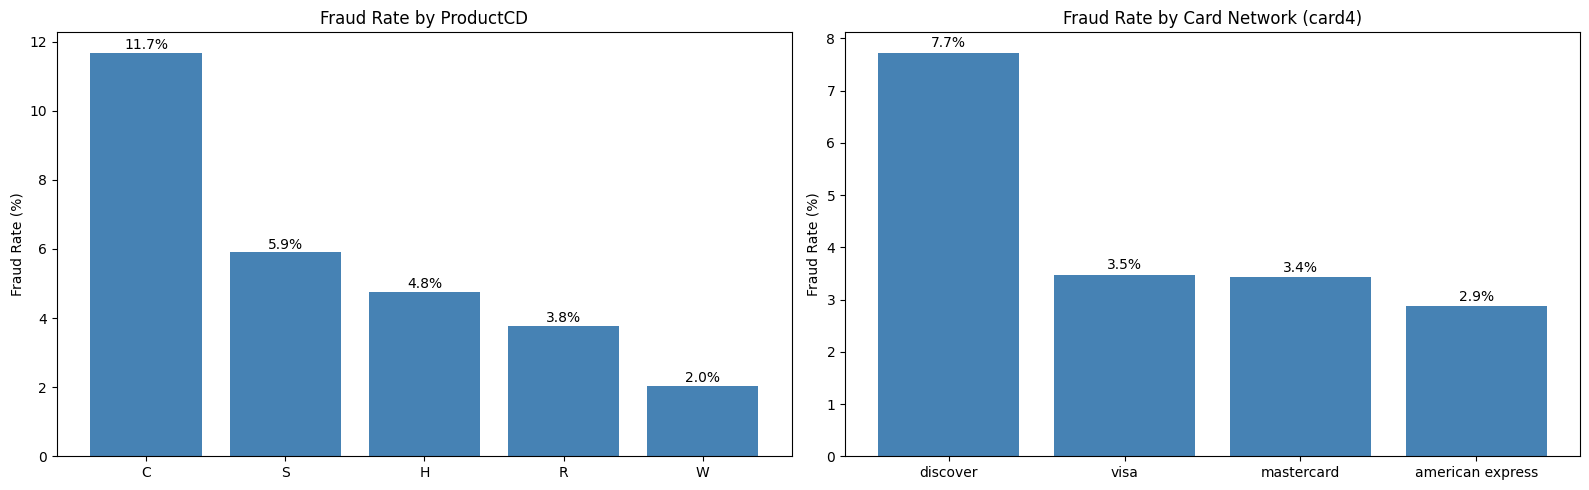

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ProductCD
prod_fraud = df.groupby('ProductCD')['isFraud'].mean().sort_values(ascending=False)
axes[0].bar(prod_fraud.index, prod_fraud.values * 100, color='steelblue')
axes[0].set_title('Fraud Rate by ProductCD')
axes[0].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(prod_fraud.values):
    axes[0].text(i, v * 100 + 0.1, f'{v*100:.1f}%', ha='center')

# Card
card_fraud = df.groupby('card4')['isFraud'].mean().sort_values(ascending=False)
axes[1].bar(card_fraud.index, card_fraud.values * 100, color='steelblue')
axes[1].set_title('Fraud Rate by Card Network (card4)')
axes[1].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(card_fraud.values):
    axes[1].text(i, v * 100 + 0.1, f'{v*100:.1f}%', ha='center')

plt.tight_layout()
plt.show()

**time-based analysis**

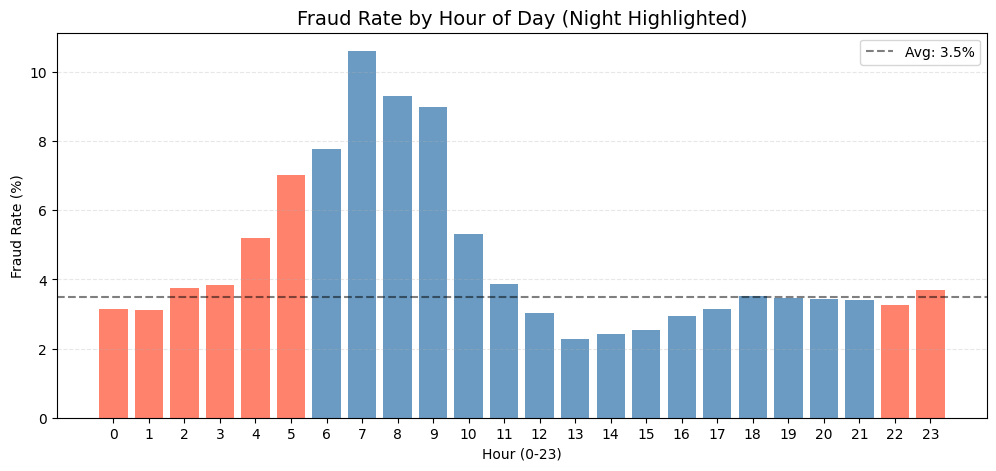

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

hourly_fraud = df['isFraud'].groupby((df['TransactionDT'] // 3600) % 24).mean()

plt.figure(figsize=(12, 5))

colors = ['tomato' if (x < 6 or x >= 22) else 'steelblue' for x in hourly_fraud.index]

plt.bar(hourly_fraud.index, hourly_fraud.values * 100, color=colors, alpha=0.8)

global_mean = df['isFraud'].mean() * 100
plt.axhline(global_mean, color='black', linestyle='--', alpha=0.5, label=f'Avg: {global_mean:.1f}%')

plt.title('Fraud Rate by Hour of Day (Night Highlighted)', fontsize=14)
plt.xlabel('Hour (0-23)')
plt.ylabel('Fraud Rate (%)')
plt.xticks(range(24))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

**card-based analysis**

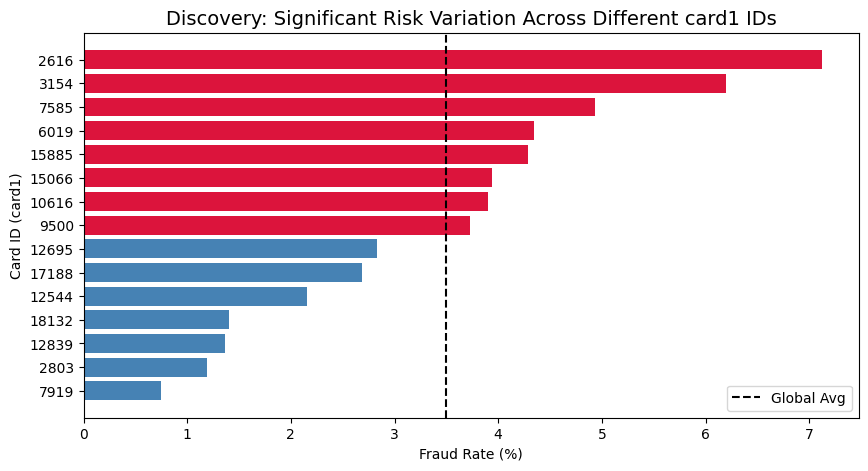

In [14]:
top_cards = df['card1'].value_counts().head(15).index
card_risk = df[df['card1'].isin(top_cards)].groupby('card1')['isFraud'].mean().sort_values()

plt.figure(figsize=(10, 5))
colors = ['steelblue' if x < card_risk.mean() else 'crimson' for x in card_risk.values]
plt.barh(card_risk.index.astype(str), card_risk.values * 100, color=colors)

plt.axvline(df['isFraud'].mean() * 100, color='black', linestyle='--', label='Global Avg')
plt.title('Discovery: Significant Risk Variation Across Different card1 IDs', fontsize=14)
plt.xlabel('Fraud Rate (%)')
plt.ylabel('Card ID (card1)')
plt.legend()
plt.show()

**dropping unnecessary columns**

In [15]:
TARGET = 'isFraud'
X = df.drop(columns=[TARGET, 'TransactionID'])
y = df[TARGET]

**splitting**

In [16]:
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Train : {X_train_raw.shape}  | fraud rate = {y_train.mean():.4f}")
print(f"Val   : {X_val_raw.shape}  | fraud rate = {y_val.mean():.4f}")

del df, X
gc.collect()

Train : (472432, 432)  | fraud rate = 0.0350
Val   : (118108, 432)  | fraud rate = 0.0350


45764

**cleaning**

In [17]:
NAN_THRESH = 0.90

run = mlflow.start_run(run_name="RF_Cleaning")
try:
    miss_ratio   = X_train_raw.isnull().mean()
    cols_to_drop = miss_ratio[miss_ratio > NAN_THRESH].index.tolist()

    X_train_c = X_train_raw.drop(columns=cols_to_drop).copy()
    X_val_c   = X_val_raw.drop(columns=cols_to_drop).copy()

    print(f"Dropped {len(cols_to_drop)} cols | Remaining: {X_train_c.shape[1]}")

    cat_cols_c = X_train_c.select_dtypes(include='object').columns.tolist()
    num_cols_c = X_train_c.select_dtypes(
        include=['float32','float64','int32','int64']).columns.tolist()

    num_medians = X_train_c[num_cols_c].median()
    X_train_c[num_cols_c] = X_train_c[num_cols_c].fillna(num_medians)
    X_val_c[num_cols_c]   = X_val_c[num_cols_c].fillna(num_medians)

    X_train_c[cat_cols_c] = X_train_c[cat_cols_c].fillna('missing')
    X_val_c[cat_cols_c]   = X_val_c[cat_cols_c].fillna('missing')

    for col in X_train_c.select_dtypes('float64').columns:
        X_train_c[col] = X_train_c[col].astype('float32')
        X_val_c[col]   = X_val_c[col].astype('float32')
    for col in X_train_c.select_dtypes('int64').columns:
        X_train_c[col] = X_train_c[col].astype('int32')
        X_val_c[col]   = X_val_c[col].astype('int32')

    print(f"NaN remaining : {X_train_c.isnull().sum().sum()}")

    mlflow.log_param("nan_threshold",    NAN_THRESH)
    mlflow.log_param("cols_dropped",     len(cols_to_drop))
    mlflow.log_param("num_imputation",   "median")
    mlflow.log_param("cat_imputation",   "constant_missing")
    mlflow.log_param("scaling",          "none_not_needed")
    mlflow.log_metric("cols_remaining",  X_train_c.shape[1])

    print("Cleaning done.")

except Exception as e:
    print(f"Error: {e}")
    raise e
finally:
    mlflow.end_run()

Dropped 12 cols | Remaining: 420
NaN remaining : 0
Cleaning done.
🏃 View run RF_Cleaning at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/6/runs/81a6a849fc884150865d8c34bc5c96b6
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/6


**feature engineering**

In [18]:
from sklearn.preprocessing import OrdinalEncoder

run = mlflow.start_run(run_name="RF_FeatureEngineering")
try:
    def add_features(df_):
        new_cols = {
            'amt_log':      np.log1p(df_['TransactionAmt']),
            'tx_hour':      (df_['TransactionDT'] // 3600) % 24,
            'tx_dayofweek': (df_['TransactionDT'] // (3600 * 24)) % 7,
            'tx_is_night':  ((df_['TransactionDT'] // 3600) % 24).apply(
                             lambda h: 1 if h < 6 or h >= 22 else 0).astype('int8'),
        }
        return pd.concat([df_, pd.DataFrame(new_cols, index=df_.index)], axis=1)

    # card aggregations
    card1_mean  = X_train_c.groupby('card1')['TransactionAmt'].mean()
    card1_count = X_train_c.groupby('card1')['TransactionAmt'].count()
    card1_std   = X_train_c.groupby('card1')['TransactionAmt'].std()
    addr1_mean  = X_train_c.groupby('addr1')['TransactionAmt'].mean()

    def add_aggs(df_):
        new_cols = {
            'card1_mean_amt':  df_['card1'].map(card1_mean).fillna(0),
            'card1_tx_count':  df_['card1'].map(card1_count).fillna(0),
            'card1_std_amt':   df_['card1'].map(card1_std).fillna(0),
            'addr1_mean_amt':  df_['addr1'].map(addr1_mean).fillna(0),
        }
        return pd.concat([df_, pd.DataFrame(new_cols, index=df_.index)], axis=1)

    X_train_fe = add_features(X_train_c)
    X_train_fe = add_aggs(X_train_fe)
    X_val_fe   = add_features(X_val_c)
    X_val_fe   = add_aggs(X_val_fe)

    cat_cols_fe = X_train_fe.select_dtypes(include='object').columns.tolist()
    enc = OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1,
        dtype='float32'
    )
    X_train_fe[cat_cols_fe] = enc.fit_transform(X_train_fe[cat_cols_fe])
    X_val_fe[cat_cols_fe]   = enc.transform(X_val_fe[cat_cols_fe])

    print(f"Features after engineering : {X_train_fe.shape[1]}")
    print(f"Extra vs DT notebook       : card1_std_amt, addr1_mean_amt")

    mlflow.log_param("new_features",    ['amt_log','tx_hour','tx_dayofweek',
                                          'tx_is_night','card1_mean','card1_count',
                                          'card1_std','addr1_mean'])
    mlflow.log_param("cat_encoding",    "OrdinalEncoder")
    mlflow.log_metric("n_features_after_fe", X_train_fe.shape[1])

    print("Feature engineering done.")

except Exception as e:
    print(f"Error: {e}")
    raise e
finally:
    mlflow.end_run()

Features after engineering : 428
Extra vs DT notebook       : card1_std_amt, addr1_mean_amt
Feature engineering done.
🏃 View run RF_FeatureEngineering at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/6/runs/b7d2511ac7e74f4c88bf067e71939992
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/6


Start : 428 features
After VarianceThreshold : 403 features
After RF Importance (top 60) : 60 features


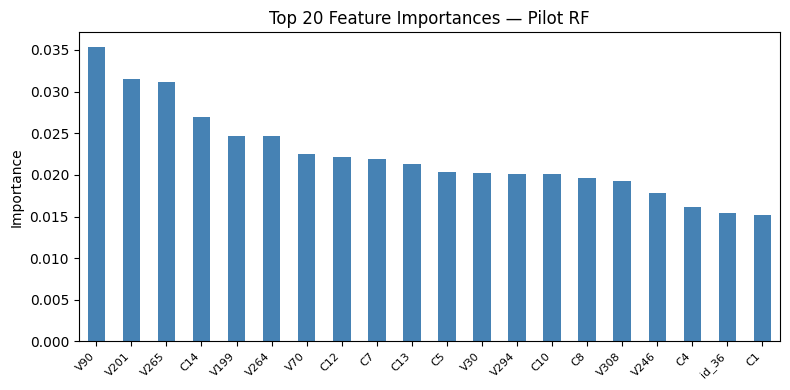

Feature selection done.
🏃 View run RF_FeatureSelection at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/6/runs/8907d26b15bc4c56b07bce3ab51337a4
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/6


In [19]:
from sklearn.ensemble import RandomForestClassifier

run = mlflow.start_run(run_name="RF_FeatureSelection")
try:
    X_tr = X_train_fe.copy()
    X_vl = X_val_fe.copy()

    print(f"Start : {X_tr.shape[1]} features")

    # Variance Threshold
    VT_THRESH = 0.01
    vt = VarianceThreshold(threshold=VT_THRESH)
    vt.fit(X_tr)
    X_tr = X_tr.loc[:, vt.get_support()]
    X_vl = X_vl.loc[:, vt.get_support()]
    print(f"After VarianceThreshold : {X_tr.shape[1]} features")

    # Pilot RF on sample
    SAMPLE_SIZE = 50_000
    idx = (pd.Series(y_train.values)
           .groupby(y_train.values)
           .apply(lambda x: x.sample(
               min(int(SAMPLE_SIZE * x.shape[0] / len(y_train)), len(x)),
               random_state=42))
           .reset_index(level=0, drop=True)
           .index)

    X_sample = X_tr.iloc[idx]
    y_sample = y_train.iloc[idx]

    pilot_rf = RandomForestClassifier(
        n_estimators=50,
        max_depth=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    pilot_rf.fit(X_sample, y_sample)

    TOP_N = 60
    importances = pd.Series(
        pilot_rf.feature_importances_,
        index=X_tr.columns
    ).sort_values(ascending=False)

    selected_features = importances.head(TOP_N).index.tolist()
    X_tr = X_tr[selected_features]
    X_vl = X_vl[selected_features]
    print(f"After RF Importance (top {TOP_N}) : {X_tr.shape[1]} features")

    plt.figure(figsize=(8, 4))
    importances.head(20).plot(kind='bar', color='steelblue')
    plt.title('Top 20 Feature Importances — Pilot RF')
    plt.ylabel('Importance')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.savefig('rf_feature_importance.png', dpi=100)
    plt.show()

    mlflow.log_param("vt_threshold",       VT_THRESH)
    mlflow.log_param("selection_method",   "PilotRF_Importance")
    mlflow.log_param("pilot_n_estimators", 50)
    mlflow.log_param("pilot_max_depth",    5)
    mlflow.log_param("pilot_sample_size",  SAMPLE_SIZE)
    mlflow.log_param("top_n_features",     TOP_N)
    mlflow.log_metric("n_features_final",  len(selected_features))
    mlflow.log_artifact("rf_feature_importance.png")

    print("Feature selection done.")

except Exception as e:
    print(f"Error: {e}")
    raise e
finally:
    mlflow.end_run()

X_train_fs = X_tr.copy()
X_val_fs   = X_vl.copy()
SELECTED_FEATURES = selected_features

**training**

In [20]:
def evaluate(model, X_tr, y_tr, X_vl, y_vl, label):
    tr_auc = roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1])
    vl_auc = roc_auc_score(y_vl, model.predict_proba(X_vl)[:, 1])
    gap    = tr_auc - vl_auc
    print(f"  {label:50s}  Train={tr_auc:.4f}  Val={vl_auc:.4f}  Gap={gap:.4f}")
    return tr_auc, vl_auc, gap

**depths**

In [21]:
depth_configs = [
    ("RF_depth2",   dict(n_estimators=100, max_depth=2,
                                   min_samples_leaf=1, class_weight='balanced',
                                   random_state=42, n_jobs=-1)),
    ("RF_depth5",            dict(n_estimators=100, max_depth=5,
                                   min_samples_leaf=1, class_weight='balanced',
                                   random_state=42, n_jobs=-1)),
    ("RF_depth10",           dict(n_estimators=100, max_depth=10,
                                   min_samples_leaf=1, class_weight='balanced',
                                   random_state=42, n_jobs=-1)),
    ("RF_depthNone", dict(n_estimators=100, max_depth=None,
                                   min_samples_leaf=1, class_weight='balanced',
                                   random_state=42, n_jobs=-1)),
]

depth_results = {}

for run_name, cfg in depth_configs:
    run = mlflow.start_run(run_name=run_name)
    try:
        model = RandomForestClassifier(**cfg)
        model.fit(X_train_fs, y_train)
        tr, vl, gap = evaluate(model, X_train_fs, y_train,
                                X_val_fs, y_val, run_name)
        mlflow.log_params(cfg)
        mlflow.log_metric("train_auc", tr)
        mlflow.log_metric("val_auc",   vl)
        mlflow.log_metric("gap",       gap)
        mlflow.set_tag("phase", "depth_sweep")
        depth_results[run_name] = {
            "model": model, "tr": tr,
            "vl": vl, "gap": gap, "cfg": cfg
        }
    finally:
        mlflow.end_run()

best_depth_run = max(depth_results, key=lambda k: depth_results[k]["vl"])
best_depth     = depth_results[best_depth_run]["cfg"]["max_depth"]
print(f"\nBest depth : {best_depth}  "
      f"Val AUC={depth_results[best_depth_run]['vl']:.4f}")

  RF_depth2                                           Train=0.8194  Val=0.8211  Gap=-0.0017
🏃 View run RF_depth2 at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/6/runs/b8d9c027b3714c92a4fe2772981b5366
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/6
  RF_depth5                                           Train=0.8489  Val=0.8473  Gap=0.0016
🏃 View run RF_depth5 at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/6/runs/21439642bae34713ae4b3b98b84e70c4
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/6
  RF_depth10                                          Train=0.8879  Val=0.8773  Gap=0.0106
🏃 View run RF_depth10 at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/6/runs/9bc11a8db2084ecc8a28ce160a45e604
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/6
  RF_depthNone                                        Train=0.9962  Val=0.8769  Gap=0.1193
🏃 View run RF_depthNone a

**leaves**

In [22]:
leaf_configs = [
    ("RF_leaf1",   dict(n_estimators=100, max_depth=best_depth,
                         min_samples_leaf=1,    class_weight='balanced',
                         random_state=42, n_jobs=-1)),
    ("RF_leaf10",  dict(n_estimators=100, max_depth=best_depth,
                         min_samples_leaf=10,   class_weight='balanced',
                         random_state=42, n_jobs=-1)),
    ("RF_leaf100", dict(n_estimators=100, max_depth=best_depth,
                         min_samples_leaf=100,  class_weight='balanced',
                         random_state=42, n_jobs=-1)),
    ("RF_leaf500", dict(n_estimators=100, max_depth=best_depth,
                         min_samples_leaf=500,  class_weight='balanced',
                         random_state=42, n_jobs=-1)),
    ("RF_leaf2000", dict(n_estimators=100, max_depth=best_depth,
                                   min_samples_leaf=2000, class_weight='balanced',
                                   random_state=42, n_jobs=-1)),
]

leaf_results = {}

for run_name, cfg in leaf_configs:
    run = mlflow.start_run(run_name=run_name)
    try:
        model = RandomForestClassifier(**cfg)
        model.fit(X_train_fs, y_train)
        tr, vl, gap = evaluate(model, X_train_fs, y_train,
                                X_val_fs, y_val, run_name)
        mlflow.log_params(cfg)
        mlflow.log_metric("train_auc", tr)
        mlflow.log_metric("val_auc",   vl)
        mlflow.log_metric("gap",       gap)
        mlflow.set_tag("phase", "leaf_sweep")
        leaf_results[run_name] = {
            "model": model, "tr": tr,
            "vl": vl, "gap": gap, "cfg": cfg
        }
    finally:
        mlflow.end_run()

best_leaf_run = max(leaf_results, key=lambda k: leaf_results[k]["vl"])
best_leaf     = leaf_results[best_leaf_run]["cfg"]["min_samples_leaf"]
print(f"\nBest min_samples_leaf : {best_leaf}  "
      f"Val AUC={leaf_results[best_leaf_run]['vl']:.4f}")

  RF_leaf1                                            Train=0.8879  Val=0.8773  Gap=0.0106
🏃 View run RF_leaf1 at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/6/runs/06f169b8a8c74305943726e4c426706c
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/6
  RF_leaf10                                           Train=0.8867  Val=0.8775  Gap=0.0092
🏃 View run RF_leaf10 at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/6/runs/6074c71d89bd4c979268f4a34486d351
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/6
  RF_leaf100                                          Train=0.8802  Val=0.8742  Gap=0.0060
🏃 View run RF_leaf100 at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/6/runs/9d9f17a5b47148b69b0b7ca8ba3c59bb
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/6
  RF_leaf500                                          Train=0.8696  Val=0.8665  Gap=0.0031
🏃 View run RF_leaf500 at: h

**n_estimators**

In [23]:
n_configs = [
    ("RF_n10",  dict(n_estimators=10,  max_depth=best_depth,
                               min_samples_leaf=best_leaf, class_weight='balanced',
                               random_state=42, n_jobs=-1)),
    ("RF_n50",           dict(n_estimators=50,  max_depth=best_depth,
                               min_samples_leaf=best_leaf, class_weight='balanced',
                               random_state=42, n_jobs=-1)),
    ("RF_n100",          dict(n_estimators=100, max_depth=best_depth,
                               min_samples_leaf=best_leaf, class_weight='balanced',
                               random_state=42, n_jobs=-1)),
    ("RF_n200",          dict(n_estimators=200, max_depth=best_depth,
                               min_samples_leaf=best_leaf, class_weight='balanced',
                               random_state=42, n_jobs=-1)),
    ("RF_n300",          dict(n_estimators=300, max_depth=best_depth,
                               min_samples_leaf=best_leaf, class_weight='balanced',
                               random_state=42, n_jobs=-1)),
]

n_results = {}

for run_name, cfg in n_configs:
    run = mlflow.start_run(run_name=run_name)
    try:
        model = RandomForestClassifier(**cfg)
        model.fit(X_train_fs, y_train)
        tr, vl, gap = evaluate(model, X_train_fs, y_train,
                                X_val_fs, y_val, run_name)
        mlflow.log_params(cfg)
        mlflow.log_metric("train_auc", tr)
        mlflow.log_metric("val_auc",   vl)
        mlflow.log_metric("gap",       gap)
        mlflow.set_tag("phase", "n_estimators_sweep")
        n_results[run_name] = {
            "model": model, "tr": tr,
            "vl": vl, "gap": gap, "cfg": cfg
        }
    finally:
        mlflow.end_run()

best_n_run = max(n_results, key=lambda k: n_results[k]["vl"])
best_n     = n_results[best_n_run]["cfg"]["n_estimators"]
print(f"\nBest n_estimators : {best_n}  "
      f"Val AUC={n_results[best_n_run]['vl']:.4f}")

  RF_n10                                              Train=0.8822  Val=0.8722  Gap=0.0100
🏃 View run RF_n10 at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/6/runs/28b6a050883547819235d059fa7974fa
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/6
  RF_n50                                              Train=0.8864  Val=0.8766  Gap=0.0098
🏃 View run RF_n50 at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/6/runs/8e43b7532aff4801b47528583bd78d04
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/6
  RF_n100                                             Train=0.8867  Val=0.8775  Gap=0.0092
🏃 View run RF_n100 at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/6/runs/d9c82349c7354205a286722426a18596
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/6
  RF_n200                                             Train=0.8871  Val=0.8777  Gap=0.0094
🏃 View run RF_n200 at: https://dags

**results**

In [24]:
all_rows = []

for name, r in depth_results.items():
    all_rows.append({
        "Phase":      "1_depth",
        "Run":        name,
        "n_est":      r["cfg"]["n_estimators"],
        "depth":      str(r["cfg"]["max_depth"]),
        "min_leaf":   r["cfg"]["min_samples_leaf"],
        "Train AUC":  round(r["tr"],  4),
        "Val AUC":    round(r["vl"],  4),
        "Gap":        round(r["gap"], 4),
    })

for name, r in leaf_results.items():
    all_rows.append({
        "Phase":      "2_leaf",
        "Run":        name,
        "n_est":      r["cfg"]["n_estimators"],
        "depth":      str(r["cfg"]["max_depth"]),
        "min_leaf":   r["cfg"]["min_samples_leaf"],
        "Train AUC":  round(r["tr"],  4),
        "Val AUC":    round(r["vl"],  4),
        "Gap":        round(r["gap"], 4),
    })

for name, r in n_results.items():
    all_rows.append({
        "Phase":      "3_n_estimators",
        "Run":        name,
        "n_est":      r["cfg"]["n_estimators"],
        "depth":      str(r["cfg"]["max_depth"]),
        "min_leaf":   r["cfg"]["min_samples_leaf"],
        "Train AUC":  round(r["tr"],  4),
        "Val AUC":    round(r["vl"],  4),
        "Gap":        round(r["gap"], 4),
    })

summary = pd.DataFrame(all_rows).sort_values(
    ["Phase", "Val AUC"], ascending=[True, False])
print(summary.to_string(index=False))

         Phase          Run  n_est depth  min_leaf  Train AUC  Val AUC     Gap
       1_depth   RF_depth10    100    10         1     0.8879   0.8773  0.0106
       1_depth RF_depthNone    100  None         1     0.9962   0.8769  0.1193
       1_depth    RF_depth5    100     5         1     0.8489   0.8473  0.0016
       1_depth    RF_depth2    100     2         1     0.8194   0.8211 -0.0017
        2_leaf    RF_leaf10    100    10        10     0.8867   0.8775  0.0092
        2_leaf     RF_leaf1    100    10         1     0.8879   0.8773  0.0106
        2_leaf   RF_leaf100    100    10       100     0.8802   0.8742  0.0060
        2_leaf   RF_leaf500    100    10       500     0.8696   0.8665  0.0031
        2_leaf  RF_leaf2000    100    10      2000     0.8575   0.8562  0.0013
3_n_estimators      RF_n300    300    10        10     0.8874   0.8781  0.0094
3_n_estimators      RF_n200    200    10        10     0.8871   0.8777  0.0094
3_n_estimators      RF_n100    100    10        10  

**best on cv**

In [25]:
best_cfg_final = {
    "n_estimators":    best_n,
    "max_depth":       best_depth,
    "min_samples_leaf": best_leaf,
    "class_weight":    "balanced",
    "random_state":    42,
    "n_jobs":          -1
}

run = mlflow.start_run(run_name="RF_CrossValidation")
try:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    cv_scores = cross_val_score(
        RandomForestClassifier(**best_cfg_final),
        X_train_fs, y_train,
        cv=cv, scoring='roc_auc', n_jobs=-1
    )

    print(f"Fold scores : {cv_scores.round(4)}")
    print(f"Mean AUC    : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    mlflow.log_params(best_cfg_final)
    mlflow.log_param("cv_folds",     5)
    mlflow.log_metric("cv_mean_auc", cv_scores.mean())
    mlflow.log_metric("cv_std_auc",  cv_scores.std())
    for i, s in enumerate(cv_scores):
        mlflow.log_metric(f"fold_{i+1}_auc", float(s))

finally:
    mlflow.end_run()

Fold scores : [0.8798 0.8745 0.8808 0.8743 0.8809]
Mean AUC    : 0.8781 ± 0.0030
🏃 View run RF_CrossValidation at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/6/runs/a7fc93741ce04210aa27a9cb6ec8e5b8
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/6


**pipeline**

In [26]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OrdinalEncoder

class DropHighNaN(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.90):
        self.threshold = threshold

    def fit(self, X, y=None):
        df_ = pd.DataFrame(X)
        miss = df_.isnull().mean()
        self.drop_cols_ = miss[miss > self.threshold].index.tolist()
        return self

    def transform(self, X):
        df_ = pd.DataFrame(X)
        return df_.drop(columns=[c for c in self.drop_cols_ if c in df_.columns])


class RFPreprocessor(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        df_ = pd.DataFrame(X)
        self.cat_cols_ = df_.select_dtypes(include='object').columns.tolist()
        self.num_cols_ = df_.select_dtypes(
            include=['float32','float64','int32','int64']).columns.tolist()

        self.medians_     = df_[self.num_cols_].median()
        self.card1_mean_  = df_.groupby('card1')['TransactionAmt'].mean().to_dict()
        self.card1_count_ = df_.groupby('card1')['TransactionAmt'].count().to_dict()

        df_cat = df_[self.cat_cols_].fillna('missing')
        self.enc_ = OrdinalEncoder(
            handle_unknown='use_encoded_value',
            unknown_value=-1,
            dtype='float32'
        )
        self.enc_.fit(df_cat)
        return self

    def transform(self, X):                         
        df_ = pd.DataFrame(X).copy()

        for col in self.num_cols_:
            if col in df_.columns:
                df_[col] = df_[col].fillna(self.medians_[col])

        for col in self.cat_cols_:
            if col in df_.columns:
                df_[col] = df_[col].fillna('missing')

        new_cols = {
            'amt_log':        np.log1p(df_['TransactionAmt']),
            'tx_hour':        (df_['TransactionDT'] // 3600) % 24,
            'tx_dayofweek':   (df_['TransactionDT'] // (3600 * 24)) % 7,
            'tx_is_night':    ((df_['TransactionDT'] // 3600) % 24).apply(
                               lambda h: 1 if h < 6 or h >= 22 else 0).astype('int8'),
            'card1_mean_amt': df_['card1'].map(self.card1_mean_).fillna(0),
            'card1_tx_count': df_['card1'].map(self.card1_count_).fillna(0),
        }

        df_ = pd.concat([df_, pd.DataFrame(new_cols, index=df_.index)], axis=1)

        cat_present = [c for c in self.cat_cols_ if c in df_.columns]
        df_[cat_present] = self.enc_.transform(df_[cat_present])

        return df_.copy()


class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df_ = pd.DataFrame(X)
        keep = [c for c in self.cols if c in df_.columns]
        return df_[keep].values

In [28]:
pipeline_rf = Pipeline([
    ('drop_nan',     DropHighNaN(threshold=0.90)),
    ('preprocessor', RFPreprocessor()),
    ('selector',     ColumnSelector(cols=SELECTED_FEATURES)),
    ('model',        RandomForestClassifier(**best_cfg_final))
])

pipeline_rf.fit(
    X_train_raw.reset_index(drop=True),
    y_train.reset_index(drop=True)
)

val_proba    = pipeline_rf.predict_proba(X_val_raw.reset_index(drop=True))[:, 1]
pipeline_auc = roc_auc_score(y_val, val_proba)
print(f"Pipeline Val AUC : {pipeline_auc:.4f}")

Pipeline Val AUC : 0.8781


**registration**

In [29]:
run = mlflow.start_run(run_name="RF_Pipeline_Registration")

try:
    mlflow.log_param("pipeline_steps", [s[0] for s in pipeline_rf.steps])

    mlflow.log_param("final_n_estimators", best_cfg_final["n_estimators"])
    mlflow.log_param("final_max_depth",    best_cfg_final["max_depth"])
    mlflow.log_param("final_max_features", best_cfg_final.get("max_features", "sqrt"))
    mlflow.log_param("final_min_samples_leaf", best_cfg_final["min_samples_leaf"])
    mlflow.log_param("final_class_weight", best_cfg_final["class_weight"])

    mlflow.log_metric("pipeline_val_auc", pipeline_auc)

    mlflow.sklearn.log_model(
        sk_model=pipeline_rf,
        artifact_path="rf_finalpipeline",
        registered_model_name="RF_FinalPipeline",
        input_example=X_train_raw.head(2)
    )

    print("Registered as : RF_FinalPipeline")
    print(f"Tracking URI : {mlflow.get_tracking_uri()}")

finally:
    mlflow.end_run()

2026/05/05 14:07:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 14:07:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can 

Registered as : RF_FinalPipeline
Tracking URI : https://dagshub.com/akeke23/ml_ass2.mlflow
🏃 View run RF_Pipeline_Registration at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/6/runs/bc5276e91a5d494691d2484b3f460c8d
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass2.mlflow/#/experiments/6
